# Presentation of results
Victor Camps, Saïd Tellez, Steven Yu

Because this project out reaches the class, we want to make sure our project is understandable outside of France.
Hence this project is in English,
A french version will be available if needed

In [128]:
# TODO: make an french version of the README.md, the code etc --> we only need to change the text, 
# not the code


## Presentation

In this project, we wanted to create a modular program to compare stochastic models to ML models to forecast the (...) volatility of a stock of the S&P500.
At the beginning of this class, we wanted to work on vanilla options on those stocks, but due to the lack of data, we we're forced to change the point of the project.

## Introduction to financial terms

In finance, a **stock** represents a fraction of ownership in a company, and its price evolves randomly over time under the influence of market forces. \
The **stock return**, often defined as the logarithmic difference between consecutive prices, measures the relative gain or loss of the asset. \
The **volatility** of a stock corresponds to the variability of these returns: mathematically, it is the standard deviation (or conditional variance) of returns over a given horizon. High volatility means large fluctuations and thus higher uncertainty or risk. \
The **VIX index**, often called the “fear index”, is a market-implied measure of expected volatility derived from S&P 500 options; it reflects investors’ anticipation of future market turbulence. 


**Accurately forecasting volatility is essential in finance** because it **underpins risk management, derivative pricing, and portfolio allocation**, all of which rely on quantifying uncertainty. 


However, **predicting volatility presents specific mathematical and machine-learning challenges**. 
**Financial time series are non-stationary and autocorrelated**, meaning that past values strongly influence the present, so data cannot be randomly shuffled as in standard ML tasks without breaking the temporal structure. \
Evaluation metrics must also reflect the asymmetric cost of errors: underestimating volatility (and thus risk) is much more damaging than overestimating it. \
For this reason, **instead of the classical Mean Squared Error, we use the QLIKE (Quasi-Likelihood) loss**, a function derived from likelihood theory in econometrics, which penalizes under-predictions more heavily and aligns better with the probabilistic modeling of variance. This intersection of mathematics and finance thus illustrates how statistical modeling, optimization, and time-series analysis combine to understand and manage financial risk.

## Presentation of the project

We tried to make the project as professional as readable as possible. Thus, we detailed the structure of the project in the README.md, but we'll make a quick summary in here.

We wanted it to be modular, so we coded the models in the folder `src\volforecast\models`, in this notebook, you will only find calls to functions coded in thoses files, to make the presentation readable. \
As part of the same idea, the evaluation methods are written in the folder `src\volforecast\evaluation`. 

We used data from Yahoo finance, using the code in the folder `src\volforecast\data`, and the csv files created are stored in the folder `data`. 

The figures created are in the folder `reports`.

To call all of the models at once, with the parameters detailed in the file `configs\default.yaml`, you can run the script `scripts\run_all.py`. Careful, it can be veery long


We we're interested to use ML models to forecast volatility, because the stochastic model is quite basic, and doesn't include a lot of parameters. Eventhough it works quite well, we wanted to try to improve it.

We tried three levels of complexity of models in this project, to balance performance with efficiency and speed of computation, because trading desks need to have fast algorithms to be the first ones to have an information, but at the same time need reliable information, to make good decisions.


Before running any code, we need to make sure we have all the latest versions of the packages

In [171]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [172]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.volforecast.visualization.plot import plot_and_save_volatility_forecast
from src.volforecast.evaluation.backtest import rolling_backtest


In [173]:
#Loading data
csv_path = "data/dataset_AAPL.csv"
df = pd.read_csv(csv_path, sep= ";", parse_dates=["Date"])
df = df.rename(columns={"Date": "date"}).sort_values("date").set_index("date")

df.head()


,AAPL_Close,SP500_Close,VIX_Close,Open,High,Low,Close,Volume,log_return_AAPL,log_return_SP500,log_return_VIX
date,,,,,,,,,,,
2010-01-05,6.435712,1136.520020,19.350000,6.442317,6.472037,6.401789,6.435712,601904800,0.001727,0.003111,-0.035038
2010-01-06,6.333344,1137.140015,19.160000,6.435713,6.461230,6.326739,6.333344,552160000,-0.016034,0.000545,-0.009868
2010-01-07,6.321635,1141.689941,19.059999,6.356759,6.364264,6.275705,6.321635,477131200,-0.001850,0.003993,-0.005233
2010-01-08,6.363666,1144.979980,18.129999,6.313232,6.364267,6.276008,6.363666,447610800,0.006627,0.002878,-0.050024
2010-01-11,6.307527,1146.979980,17.549999,6.388281,6.394285,6.257693,6.307527,462229600,-0.008861,0.001745,-0.032514


In [174]:
train_start = df.index.min()
train_end   = df.index[150]   

## Presentation of each model

### Presentation of the GARCH Model

In [175]:
import os
print(os.getcwd()) # to check the current working directory (it must be the root directory of the project)

c:\Users\vicca\Desktop\Centrale\EI3\STASC\volatility-forecast


In [208]:
from src.volforecast.models.garch_model import GARCHConfig, GARCHVolModel
from src.volforecast.models.base import BaseConfig, BaseVolModel

In [209]:
# 1) Configs
base_cfg = BaseConfig(  # optional overrides if your cols differ
    date_col="date",
    return_col="log_return_AAPL",  # column used to create the realized-variance target
    target_shift=-1,          # predict t+1 realized variance with info up to t
    eps=1e-8
)
garch_cfg = GARCHConfig(
    **base_cfg.__dict__,
    p=1,
    q=1,
    o=0,
    dist="normal",
    mean="zero"
)

# 3) Model
garch_model = GARCHVolModel(garch_cfg)


In [214]:
# If your data is trading days, prefer business-day steps:
garch_results = rolling_backtest(
    model=garch_model,
    df=df,
    train_start=train_start,
    train_end=train_end,
    step="1B",   # use "1D" only if calendar is daily with no gaps
    min_history= 20,
    fixed_window=750
)

c:\Users\vicca\Desktop\Centrale\EI3\STASC\volatility-forecast\.venv\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0003571. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
c:\Users\vicca\Desktop\Centrale\EI3\STASC\volatility-forecast\.venv\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0003639. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=Fals

In [215]:
print(garch_results)

{'metrics': {'RMSE': 0.0007921034575583549, 'MAE': 0.000340623343622738, 'QLIKE': -7.239257456595744, 'n': 3622}, 'y_true': date
2010-08-11    0.000081
2010-08-12    0.001310
2010-08-13    0.000041
2010-08-16    0.000115
2010-08-17    0.000035
                ...   
2024-12-24    0.000009
2024-12-26    0.000130
2024-12-27    0.000010
2024-12-30    0.000178
2024-12-31    0.000178
Name: y_true, Length: 3622, dtype: float64, 'y_pred': 2010-08-11    0.000221
2010-08-12    0.000222
2010-08-13    0.000344
2010-08-16    0.000331
2010-08-17    0.000298
                ...   
2024-12-24    0.000170
2024-12-26    0.000165
2024-12-27    0.000166
2024-12-30    0.000160
2024-12-31    0.000164
Name: y_pred, Length: 3622, dtype: float64}


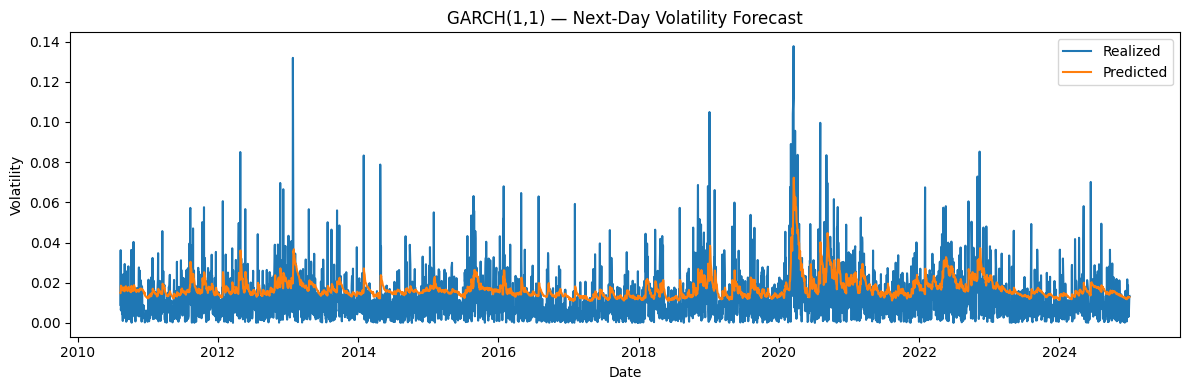


Metrics:
RMSE: 0.000792
MAE: 0.000341
QLIKE: -7.239257
n: 3622.000000


In [217]:
plot_and_save_volatility_forecast(
    garch_results,
    title="GARCH(1,1) — Next-Day Volatility Forecast",
    save=False,                         
    show=True,
    plot_as_vol=True                         
)

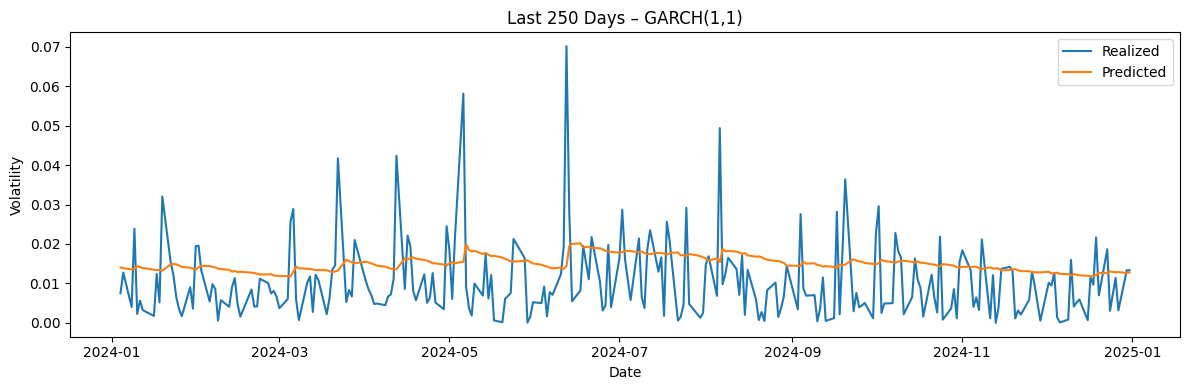


Metrics:
RMSE: 0.000792
MAE: 0.000341
QLIKE: -7.239257
n: 3622.000000


In [226]:
y_true = garch_results["y_true"]
y_pred = garch_results["y_pred"]
valid  = y_true.notna() & y_pred.notna()
idx_250 = valid[valid].index[-250:]   # last 250 timestamps where both exist

res_250 = {
    "y_true": y_true.loc[idx_250],
    "y_pred": y_pred.loc[idx_250],
    "metrics": garch_results.get("metrics", {}),
}


plot_and_save_volatility_forecast(
    res=res_250,
    title="Last 250 Days – GARCH(1,1)",  # edit the title to match your model
    show=True,
    save=False,
    plot_as_vol=True,  
)

### Presentation of the Linear regression with Elasticnet CV


The first one is the simplest model, it is a linear regression with elasticnet cross validation. The objective of this one is to be computationnaly quick. We wanted to see if the vol forecast could be linear in a short period. We don't expect quality results

We have to import tha model

In [193]:
from src.volforecast.models.base import BaseConfig, BaseVolModel

In [194]:
from src.volforecast.models.elasticnet_regression_model import ElasticNetConfig, ElasticNetVolModel
from src.volforecast.features.builders import FeatureBuilder

In [195]:
# 1) Configs
base_cfg = BaseConfig(  # optional overrides if your cols differ
    date_col="date",
    return_col="log_return_AAPL",  # column used to create the realized-variance target
    target_shift=-1,          # predict t+1 realized variance with info up to t
    eps=1e-8
)
enet_cfg = ElasticNetConfig(
    **base_cfg.__dict__,
    alphas=(1e-4, 1e-3, 1e-2, 1e-1, 1.0),
    l1_ratio=(0.1, 0.5, 0.9),
    cv_splits=5,
    use_log_target=True,   # trains on log(target); auto-inverted at predict time
    scale_features=True
)

# 2) Features
enet_builder = FeatureBuilder(
    lags_returns=(1, 2, 3, 4, 5),
    lags_vix=(1, 2, 3, 4, 5),
    add_dow=True,
    date_col="date",
    return_col="log_return_AAPL",
    vix_col="log_return_VIX"
)

# 3) Model
enet_model = ElasticNetVolModel(enet_cfg, enet_builder)


In [196]:
# If your data is trading days, prefer business-day steps:
enet_results = rolling_backtest(
    model=enet_model,
    df=df,
    train_start=train_start,
    train_end=train_end,
    step="1B",   # use "1D" only if calendar is daily with no gaps
    min_history= 20,
    fixed_window=750
)

In [197]:
print(enet_results)

{'metrics': {'RMSE': 0.0008713414306429433, 'MAE': 0.0002816838252437711, 'QLIKE': -3.1763607562008613, 'n': 3622}, 'y_true': date
2010-08-11    0.000081
2010-08-12    0.001310
2010-08-13    0.000041
2010-08-16    0.000115
2010-08-17    0.000035
                ...   
2024-12-24    0.000009
2024-12-26    0.000130
2024-12-27    0.000010
2024-12-30    0.000178
2024-12-31    0.000178
Name: y_true, Length: 3622, dtype: float64, 'y_pred': 2010-08-11    0.000091
2010-08-12    0.000113
2010-08-13    0.000155
2010-08-16    0.000108
2010-08-17    0.000109
                ...   
2024-12-24    0.000046
2024-12-26    0.000034
2024-12-27    0.000063
2024-12-30    0.000065
2024-12-31    0.000073
Name: y_pred, Length: 3622, dtype: float64}


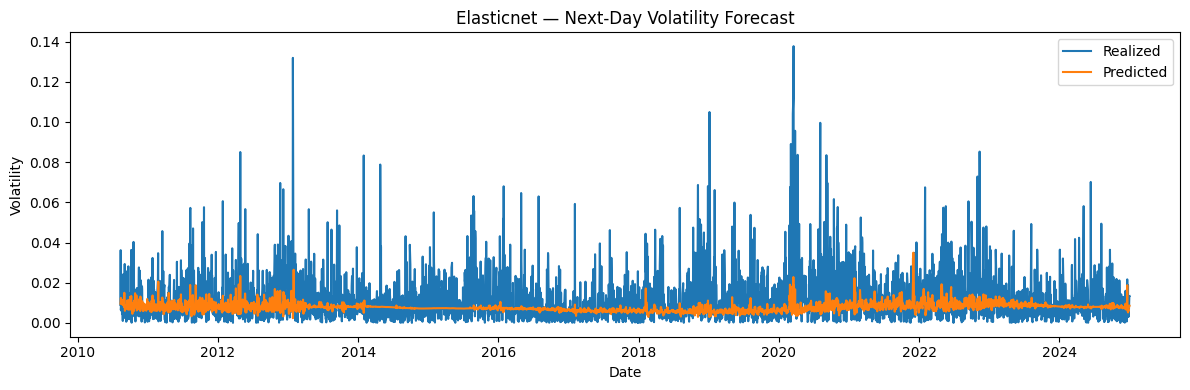


Metrics:
RMSE: 0.000871
MAE: 0.000282
QLIKE: -3.176361
n: 3622.000000


In [202]:
plot_and_save_volatility_forecast(
    enet_results,
    title="Elasticnet — Next-Day Volatility Forecast",
    save=False,                         
    show=True,
    plot_as_vol=True                          
)

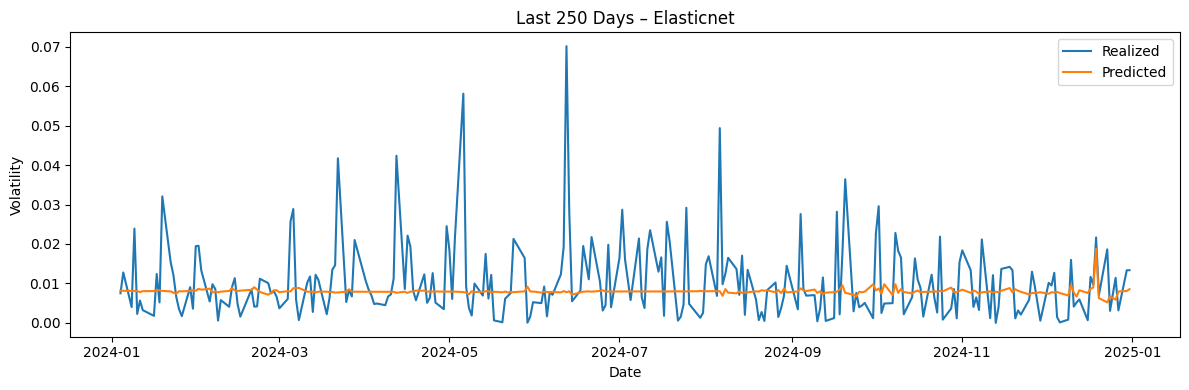


Metrics:
RMSE: 0.000871
MAE: 0.000282
QLIKE: -3.176361
n: 3622.000000


In [225]:
y_true = enet_results["y_true"]
y_pred = enet_results["y_pred"]
valid  = y_true.notna() & y_pred.notna()
idx_250 = valid[valid].index[-250:]   # last 250 timestamps where both exist

res_250 = {
    "y_true": y_true.loc[idx_250],
    "y_pred": y_pred.loc[idx_250],
    "metrics": enet_results.get("metrics", {}),
}


plot_and_save_volatility_forecast(
    res=res_250,
    title="Last 250 Days – Elasticnet",  # edit the title to match your model
    show=True,
    save=False,
    plot_as_vol=True,  
)

In [199]:
summary = enet_model.summary()

best_alpha = float(summary["best_alpha"])
best_l1_ratio = float(summary["best_l1_ratio"])

display(summary)
print(f"Best alpha: {best_alpha:.6f}")
print(f"Best l1_ratio: {best_l1_ratio:.6f}")


{'coefficients': {'lag_returns_1': 0.07604246991591057,
  'lag_returns_2': -0.0574232745307415,
  'lag_returns_3': -0.10457027927030338,
  'lag_returns_4': 0.0,
  'lag_returns_5': -0.02899287206029322,
  'lag_vix_1': 0.23157529225967027,
  'lag_vix_2': -0.0,
  'lag_vix_3': -0.0,
  'lag_vix_4': 0.022420451174966848,
  'lag_vix_5': 0.0},
 'best_alpha': np.float64(0.1),
 'best_l1_ratio': np.float64(0.5)}

Best alpha: 0.100000
Best l1_ratio: 0.500000


We can see that the model uses a lot more of L2 loss than L1 loss, so there's not a big selection of features, all are used basically
The best alpha is quite low, we don't penalize a lot --> maybe that's why QLIKE loss is that high ?

We could expect this as the linear model is too simple to forecast the volatility.
What we can learn abt this is that the RMSE and the MAE are quite small, because the forecast is correct or close to correct a lot of times, but the QLIKE loss is very high, since it penalizes a lot underpredictions. Hence, this model is not usable in that way.

TODO: Add conclusions abt what coefficients are the most important and the less important

### Presentation of the LSTM Model

The Deep LSTM model combines convolutional layers to extract temporal patterns and LSTM layers to capture long-term dependencies in financial time series. Unlike linear models, it can learn complex nonlinear relationships between past returns and future volatility.

Here we demonstrate training the model on all available data with real-time monitoring of training and validation losses.

In [ ]:
from src.volforecast.models.deep_econo_net import DeepEconoNet, DeepEconoNetConfig

In [ ]:
# Configure and train the LSTM model
lstm_config = DeepEconoNetConfig(
    seq_len=20,
    learning_rate=1e-3,
    batch_size=32,
    epochs=20,
    train_val_ratio=0.8,
    device="cpu"  # Change to "cuda" if GPU available
)

lstm_model = DeepEconoNet(lstm_config)

# Train on all data with real-time plotting (decorator handles this automatically)
lstm_model.train_pipeline(
    data_dir="data/stock_info",
    pattern="*_dataset.csv",
    normalization_fraction=0.8,
    feature_col="Log_Return",
    target_col="RealVol_5d",
    verbose=True  # This enables real-time loss tracking and plotting
)

### Presentation of XGBoost Model

XGBoost (Extreme Gradient Boosting) is a powerful machine learning algorithm based on an ensemble of decision trees trained sequentially to correct each other’s errors. \
It can model nonlinear relationships and interactions between variables such as past returns and VIX levels, without assuming any specific distribution. \
Thanks to its regularization and robustness to outliers, XGBoost can effectively capture volatility clustering and complex market dynamics that traditional linear or parametric models like GARCH might miss. \
Here's how we implemented it and the results


In [147]:
import sys
print(sys.executable)


c:\Users\vicca\Desktop\Centrale\EI3\STASC\volatility-forecast\.venv\Scripts\python.exe


In [148]:
from src.volforecast.models.xgboost_model import XGBoostConfig, XGBoostVolModel

In [168]:
# 1) Configs
base_cfg = BaseConfig(  # optional overrides if your cols differ
    date_col="date",
    return_col="log_return_AAPL",  # column used to create the realized-variance target
    target_shift=-1,          # predict t+1 realized variance with info up to t
    eps=1e-8
)
xgboost_cfg = XGBoostConfig(
    **base_cfg.__dict__,
    n_estimators= 50,
    learning_rate= 0.05,
    max_depth= 4,
    subsample= 0.8,
    colsample_bytree= 0.8,
    use_log_target= True,
    random_state= 42
)

# 2) Features
xgboost_builder = FeatureBuilder(
    lags_returns=(1, 2, 3, 4, 5),
    lags_vix=(1, 2, 3, 4, 5),
    add_dow=True,
    date_col="date",
    return_col="log_return_AAPL",
    vix_col="log_return_VIX"
)

# 3) Model
xgboost_model = XGBoostVolModel(xgboost_cfg, xgboost_builder)


In [169]:
# After reading your CSV
df = pd.read_csv("data/dataset_AAPL.csv", sep=";", parse_dates=["Date"])
df = df.rename(columns={"Date": "date"}).sort_values("date").set_index("date")

# Now these are timestamps, not ints:
train_start = df.index.min()
train_end   = df.index[150]        # this is a Timestamp now

# If your data is trading days, prefer business-day steps:
xgboost_results = rolling_backtest(
    model=xgboost_model,
    df=df,
    train_start=train_start,
    train_end=train_end,
    step="1B",   # use "1D" only if calendar is daily with no gaps
    min_history= 20,
    fixed_window=750
)


In [170]:
print(xgboost_results)

{'metrics': {'RMSE': 0.0006260454306379246, 'MAE': 0.00011395324664447517, 'QLIKE': -8.741924756730194, 'n': 3622}, 'y_true': date
2010-08-11    0.000081
2010-08-12    0.001310
2010-08-13    0.000041
2010-08-16    0.000115
2010-08-17    0.000035
                ...   
2024-12-24    0.000009
2024-12-26    0.000130
2024-12-27    0.000010
2024-12-30    0.000178
2024-12-31    0.000178
Name: y_true, Length: 3622, dtype: float64, 'y_pred': 2010-08-11    0.000083
2010-08-12    0.000960
2010-08-13    0.000049
2010-08-16    0.000114
2010-08-17    0.000039
                ...   
2024-12-24    0.000012
2024-12-26    0.000116
2024-12-27    0.000009
2024-12-30    0.000138
2024-12-31    0.000139
Name: y_pred, Length: 3622, dtype: float32}


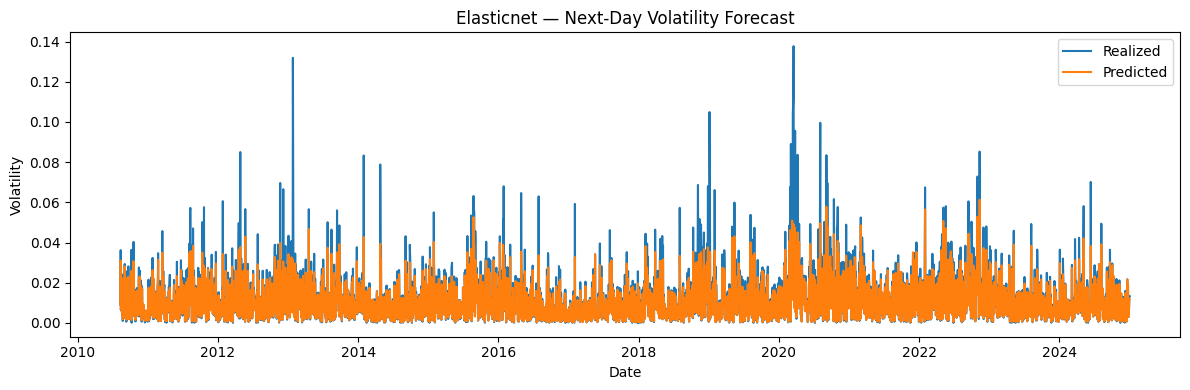


Metrics:
RMSE: 0.000626
MAE: 0.000114
QLIKE: -8.741925
n: 3622.000000


In [218]:
plot_and_save_volatility_forecast(
    xgboost_results,
    title="Elasticnet — Next-Day Volatility Forecast",
    save=False,                         
    show=True,
    plot_as_vol=True                          
)

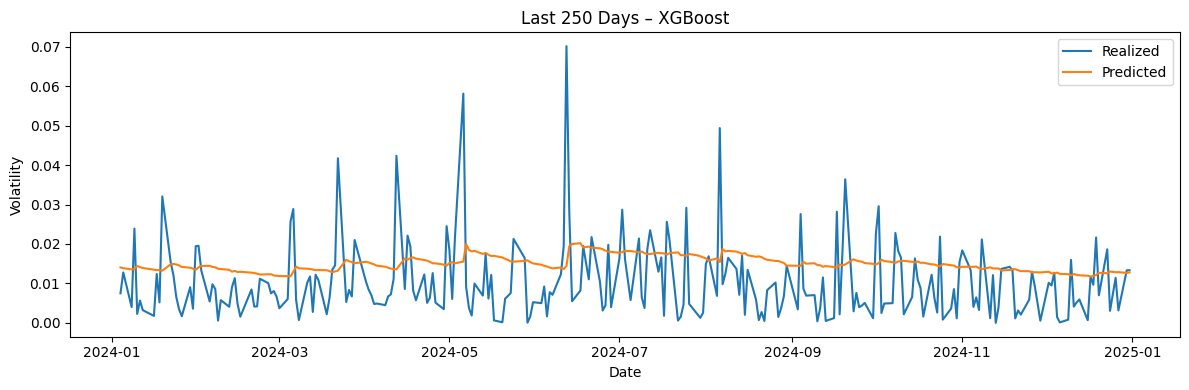


Metrics:
RMSE: 0.000792
MAE: 0.000341
QLIKE: -7.239257
n: 3622.000000


In [227]:
y_true = garch_results["y_true"]
y_pred = garch_results["y_pred"]
valid  = y_true.notna() & y_pred.notna()
idx_250 = valid[valid].index[-250:]   # last 250 timestamps where both exist

res_250 = {
    "y_true": y_true.loc[idx_250],
    "y_pred": y_pred.loc[idx_250],
    "metrics": garch_results.get("metrics", {}),
}


plot_and_save_volatility_forecast(
    res=res_250,
    title="Last 250 Days – XGBoost",  # edit the title to match your model
    show=True,
    save=False,
    plot_as_vol=True,  
)

In [151]:
# Evaluate performance
xgb_metrics = xgboost_model.evaluate(df)

# Display results
print("XGBoost Model Evaluation:")
for k, v in xgb_metrics.items():
    print(f"{k:8s}: {v:.6f}" if isinstance(v, float) else f"{k:8s}: {v}")

XGBoost Model Evaluation:
RMSE    : 0.000381
MAE     : 0.000034
QLIKE   : -8.815343
n       : 3768


In [152]:
xgboost_summary = xgboost_model.summary()

display(xgboost_summary)

{'n_features': 10,
 'best_params': {'objective': 'reg:squarederror',
  'base_score': None,
  'booster': None,
  'callbacks': None,
  'colsample_bylevel': None,
  'colsample_bynode': None,
  'colsample_bytree': 0.8,
  'device': None,
  'early_stopping_rounds': None,
  'enable_categorical': False,
  'eval_metric': None,
  'feature_types': None,
  'feature_weights': None,
  'gamma': None,
  'grow_policy': None,
  'importance_type': None,
  'interaction_constraints': None,
  'learning_rate': 0.05,
  'max_bin': None,
  'max_cat_threshold': None,
  'max_cat_to_onehot': None,
  'max_delta_step': None,
  'max_depth': 4,
  'max_leaves': None,
  'min_child_weight': None,
  'missing': nan,
  'monotone_constraints': None,
  'multi_strategy': None,
  'n_estimators': 500,
  'n_jobs': None,
  'num_parallel_tree': None,
  'random_state': 42,
  'reg_alpha': None,
  'reg_lambda': None,
  'sampling_method': None,
  'scale_pos_weight': None,
  'subsample': 0.8,
  'tree_method': None,
  'validate_parameter

### Comparaison des résultats


In [228]:
import pandas as pd

# Create a comparison table
metrics_df = pd.DataFrame({
    "GARCH": garch_results["metrics"],
    "ElasticNet": enet_results["metrics"],
    "XGBoost": xgboost_results["metrics"],
}).T

# Format RMSE and MAE in scientific notation
metrics_df["RMSE"] = metrics_df["RMSE"].map(lambda x: f"{x:.2e}")
metrics_df["MAE"]  = metrics_df["MAE"].map(lambda x: f"{x:.2e}")

# Round QLIKE to 3 decimals for clarity
metrics_df["QLIKE"] = metrics_df["QLIKE"].round(3)

# Reorder columns
metrics_df = metrics_df[["RMSE", "MAE", "QLIKE", "n"]]

# Display with a clear title
print(" Model Performance Comparison (scientific notation for losses)")
display(metrics_df)


 Model Performance Comparison (scientific notation for losses)


,RMSE,MAE,QLIKE,n
GARCH,7.92e-04,3.41e-04,-7.239,3622.0
ElasticNet,8.71e-04,2.82e-04,-3.176,3622.0
XGBoost,6.26e-04,1.14e-04,-8.742,3622.0


## Pour aller plus loin

On pourrait regarder de faire un transformer pour prédire la vol à partir d'analyse de sentiments, à partir de données sur twitter ou sur des chaînes d'infos --> embedding de mots récurrents comme features sur la vol ?